**이번 실험은 LSTM+Attention과 Summa를 비교한다.
LSTM+Attention은 전처리 된 데이터로 학습을, Summa는 전처리 되지 않은 데이터로 학습을 진행하기에 중간에 Summa를 위해 결측치만 제거한 데이터를 따로 저장해 둠**

### 버전 확인하기

In [3]:
!pip install --upgrade summa
!pip install --upgrade nltk #3.9.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for summa: filename=summa-1.2.0-py3-none-any.whl size=54387 sha256=935352b5796c4aa5e90398f0f79abb650c69f8ffcc19dc5dafe3ca59f56ca074
  Stored in directory: /root/.cache/pip/wheels/70/26/84/58df5a55ebde6fd802666b6ac0b86909ecd018a2702b89d13c
Successfully built summa
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.6 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1


In [4]:
from importlib.metadata import version
import nltk
import torch
import summa
import pandas as pd

print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

3.10.3
2.11.0+cu128
2.2.2
1.2.0


# 1. 데이터 다운 받기
- 뉴스 기사 데이터
  - **headlines 컬럼**: 기사 제목
  - **text 컬럼**: 기사 본문
- 추출적 요약시: text 컬럼만 이용
- 추상적 요약시: headlines, text 컬럼 이용

In [4]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

data.sample(10)

,headlines,text
69334,Gurmeet Ram 'most well-behaved' prisoner: Hary...,The Haryana Police has said that rape-convict ...
63610,Apple fires engineer after daughter posts iPho...,"The daughter of an Apple engineer, Brooke Pete..."
16951,Uber in talks to buy Dubai ride-hailing firm C...,US-based ride-hailing company Uber is in talks...
52408,Hardik booked for 'political' speech at farmer...,Patidar leader Hardik Patel was booked on Frid...
76528,Mumbai: 16 Somali pirates jailed for 7 yrs for...,A Mumbai court on Monday sentenced 16 Somali p...
38896,9 bars at prominent Delhi spots caught serving...,During surprise inspections between August 201...
51980,VHP leader Togadia staged his disappearance: P...,Dismissing VHP leader Pravin Togadia's claims ...
87305,Mumbai students protest compulsion of Aadhaar ...,Students of the Mumbai's Tata Institute of Soc...
84538,1-bedroom home by world's largest active volca...,A one-bedroom house near the world's largest a...
90286,New trailer of Christopher Nolan's 'Dunkirk' r...,A new trailer of Christopher Nolan's upcoming ...


# 2. EDA

In [5]:
print('=========== 행, 열 수 ===========')
print(data.shape, '\n')
print('=========== data.info ===========')
print(data.info(), '\n')
print('=========== 중복을 제외한 값 ===========')
print(data['text'].nunique())
print(data['headlines'].nunique())

=========== 행, 열 수 ===========
(98401, 2) 

=========== data.info ===========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98401 entries, 0 to 98400
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   headlines  98401 non-null  object
 1   text       98401 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB
None 

=========== 중복을 제외한 값 ===========
98360
98280


In [6]:
# 컬럼 별 데이터 길이 분포 확인하기 (문자 수)
temp = pd.DataFrame()
temp['text_len'] = data['text'].str.len()
temp['headline_len'] = data['headlines'].str.len()

temp[['text_len', 'headline_len']].describe()

,text_len,headline_len
count,98401.000000,98401.000000
mean,357.544161,57.643337
std,24.647988,4.878594
min,4.000000,9.000000
25%,341.000000,56.000000
50%,358.000000,59.000000
75%,376.000000,60.000000
max,513.000000,86.000000


,text_word_count,headline_word_count
count,98401.000000,98401.000000
mean,58.238534,9.553907
std,2.384053,1.457955
min,1.000000,1.000000
25%,57.000000,9.000000
50%,59.000000,10.000000
75%,60.000000,10.000000
max,91.000000,18.000000


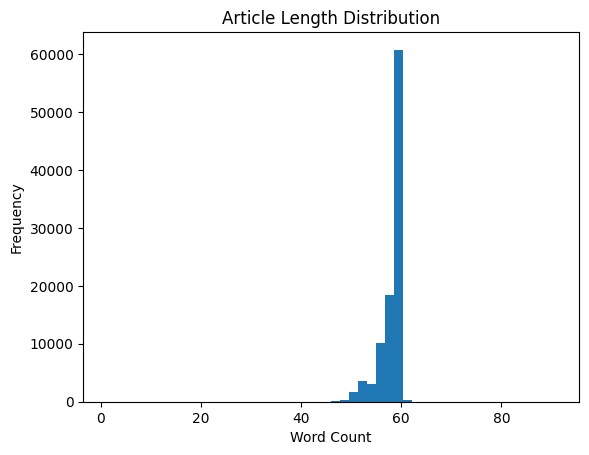

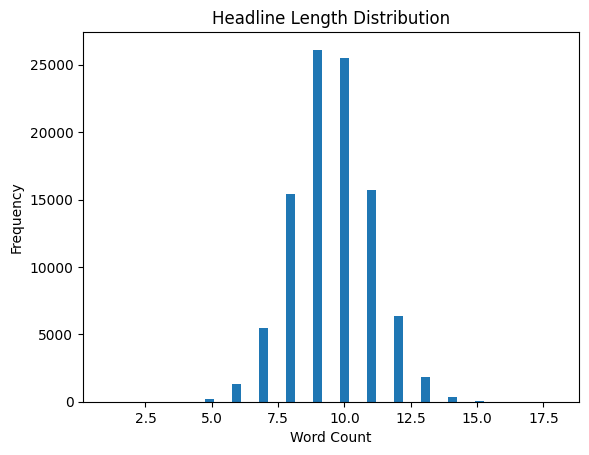

In [7]:
# 컬럼 별 데이터 단어 갯수 분포 확인하기 (단어 수)
temp['text_word_count'] = data['text'].str.split().str.len()
temp['headline_word_count'] = data['headlines'].str.split().str.len()

display(temp[['text_word_count', 'headline_word_count']].describe())

# 시각화
import matplotlib.pyplot as plt

plt.hist(temp['text_word_count'], bins=50)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Article Length Distribution')
plt.show()

plt.hist(temp['headline_word_count'], bins=50)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Headline Length Distribution')
plt.show()

In [8]:
# 특수문자 비율
import re

temp['text_special_count'] = data['text'].apply(
    lambda x: len(re.findall(r'[^a-zA-Z0-9\s]', x))
)
temp['headlines_special_count'] = data['headlines'].apply(
    lambda x: len(re.findall(r'[^a-zA-Z0-9\s]', x))
)

temp[['text_special_count', 'headlines_special_count']].describe()

,text_special_count,headlines_special_count
count,98401.000000,98401.000000
mean,11.593663,1.694424
std,5.927323,1.984796
min,0.000000,0.000000
25%,8.000000,0.000000
50%,10.000000,1.000000
75%,14.000000,2.000000
max,163.000000,32.000000


# 3. 데이터 전처리

### 중복 제거

In [9]:
print('원본 데이터 수:', len(data))
print('headlines 열에서 중복을 배제한 유일한 샘플의 수:', data['headlines'].nunique())
print('text 열에서 중복을 배제한 유일한 샘플의 수:', data['text'].nunique())

원본 데이터 수: 98401
headlines 열에서 중복을 배제한 유일한 샘플의 수: 98280
text 열에서 중복을 배제한 유일한 샘플의 수: 98360


In [10]:
# text 컬럼이 중복인 행을 우선 제거 후 headlines 컬럼에서 중복 행 제거
data.drop_duplicates(subset = ['text'], inplace=True)
data.drop_duplicates(subset = ['headlines'], inplace=True)
print('전체 샘플수 :', (len(data)))
print('\n', data.isnull().sum())

전체 샘플수 : 98262

 headlines    0
text         0
dtype: int64


### train(80%), validation(10%), test(10%) 데이터로 분리하기

In [11]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

val, test = train_test_split(
    temp,
    test_size=0.5,
    random_state=42
)

In [12]:
# Summa에서 사용할 전처리를 수행하지 않은 데이터 저장

train_raw = train.copy()
val_raw = val.copy()
test_raw = test.copy()

train_raw.to_csv(
    '/content/drive/MyDrive/summa_train.csv',
    index=False,
    encoding='utf-8-sig'
)

val_raw.to_csv(
    '/content/drive/MyDrive/summa_val.csv',
    index=False,
    encoding='utf-8-sig'
)

test_raw.to_csv(
    '/content/drive/MyDrive/summa_test.csv',
    index=False,
    encoding='utf-8-sig'
)

### 텍스트 정규화 및 불용어 제거
  - [정규화 사전 출처](https://stackoverflow.com/questions/19790188/expanding-english-language-contractions-in-python)

In [12]:
import nltk
nltk.pathsec.ALLOW_PROXIED_FETCH = True
nltk.download("stopwords")

import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from bs4 import BeautifulSoup

import torch
from collections import Counter

import urllib.request
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='bs4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [14]:
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print("정규화 사전의 수: ", len(contractions))

정규화 사전의 수:  120


In [15]:
print('불용어 개수 :', len(stopwords.words('english') ))
print(stopwords.words('english'))

# headlines 컬럼은 비교적 길이가 짧기 때문에 불용어를 제거하지 않을 예정

불용어 개수 : 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

In [16]:
# 데이터 전처리 함수
def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower()                            # 텍스트 소문자화
    sentence = BeautifulSoup(sentence, "lxml").text        # <br />, <a href = ...> 등의 html 태그 제거
    sentence = re.sub(r'\([^)]*\)', '', sentence)          # 괄호로 닫힌 문자열 (...) 제거 Ex) my husband (and myself!) for => my husband for
    sentence = re.sub('"','', sentence)                    # 쌍따옴표 제거
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")])      # 약어 정규화
    sentence = re.sub(r"'s\b","", sentence)                # 소유격 제거. Ex) roland's -> roland
    sentence = re.sub("[^a-zA-Z]", " ", sentence)          # 영어 외 문자(숫자, 특수문자 등) 공백으로 변환
    sentence = re.sub('[m]{2,}', 'mm', sentence)           # m이 3개 이상이면 2개로 변경. Ex) ummmmmmm yeah -> umm yeah

    # 불용어 제거 (text)
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if not word in stopwords.words('english') if len(word) > 1)
    # 불용어 미제거 (headlines)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    return tokens

In [17]:
# 테스트
temp_text = 'Everything I bought was great, infact I ordered twice and the third ordered was<br />for my mother and father.'
temp_headlines = 'Great way to start (or finish) the day!!!'

print("text: ", preprocess_sentence(temp_text))
print("headlines:", preprocess_sentence(temp_headlines, False))  # 불용어를 제거하지 않습니다.

text:  everything bought great infact ordered twice third ordered wasfor mother father
headlines: great way to start the day


In [18]:
# Train
train['text'] = train['text'].apply(preprocess_sentence)
train['headlines'] = train['headlines'].apply(lambda x: preprocess_sentence(x, remove_stopwords=False))


# Validation
val['text'] = val['text'].apply(preprocess_sentence)
val['headlines'] = val['headlines'].apply(lambda x: preprocess_sentence(x, remove_stopwords=False))


# Test
test['text'] = test['text'].apply(preprocess_sentence)
test['headlines'] = test['headlines'].apply(lambda x: preprocess_sentence(x, remove_stopwords=False))


# 결과 확인
print("Train text 전처리 결과:")
print(train['text'].head())

print("\nTrain headlines 전처리 결과:")
print(train['headlines'].head())

print("\nValidation text 전처리 결과:")
print(val['text'].head())

print("\nTest text 전처리 결과:")
print(test['text'].head())

Train text 전처리 결과:
31373    residents karnataka tarkaspet village boycotte...
16457    kerala mla pc george earlier called kerala nun...
79503    chuck bundrant founder majority owner trident ...
78241    forming government alliance janata dal bihar b...
48993    vice president rajya sabha chairman venkaiah n...
Name: text, dtype: object

Train headlines 전처리 결과:
31373    karnataka village locals boycott voting in sta...
16457    have photos showing nun happy after alleged ra...
79503    us man who once sold trash fish is now billion...
78241          bjp and its allies now rule states in india
48993    do not call me his excellency rajya sabha chai...
Name: headlines, dtype: object

Validation text 전처리 결과:
40284    using data nasa kepler space telescope astrono...
56335    us federal communications commission chief tec...
2980     almost month got married mumbai isha ambani an...
15511    pakistan superfan bashir chacha also known cha...
69698    brihanmumbai municipal corporation prop

- 위에 코드까지는(전처리) cpu, 아래부터는 gpu 사용
- 런타임 유형 변경 시 런타임이 끊김으로 구글 드라이브에 data 저장 후 다시 불러옴

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
# 전처리된 LSTM용 데이터 저장

train.to_csv(
    '/content/drive/MyDrive/train.csv',
    index=False,
    encoding='utf-8-sig'
)

val.to_csv(
    '/content/drive/MyDrive/val.csv',
    index=False,
    encoding='utf-8-sig'
)

test.to_csv(
    '/content/drive/MyDrive/test.csv',
    index=False,
    encoding='utf-8-sig'
)

print("Train, Validation, Test 데이터 저장 완료")

Train, Validation, Test 데이터 저장 완료


In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [92]:
import pandas as pd

train = pd.read_csv(
    '/content/drive/MyDrive/train.csv',
    encoding='utf-8-sig'
)

val = pd.read_csv(
    '/content/drive/MyDrive/val.csv',
    encoding='utf-8-sig'
)

test = pd.read_csv(
    '/content/drive/MyDrive/test.csv',
    encoding='utf-8-sig'
)

### 텍스트 데이터의 최대 길이 정하기

텍스트의 최소 길이 : 1
텍스트의 최대 길이 : 60
텍스트의 평균 길이 : 35.10575124985689
요약의 최소 길이 : 1
요약의 최대 길이 : 16
요약의 평균 길이 : 9.305130455800226


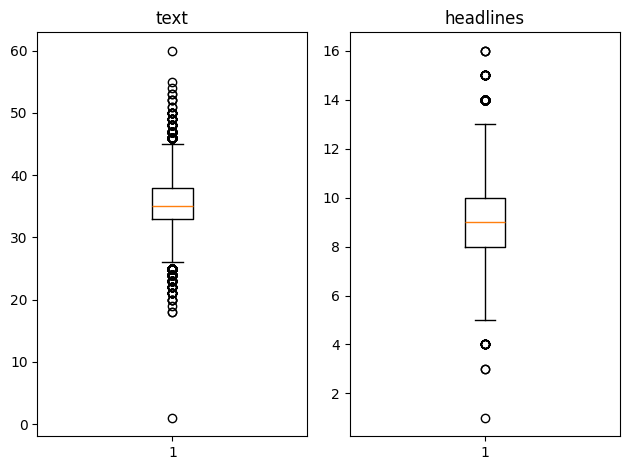

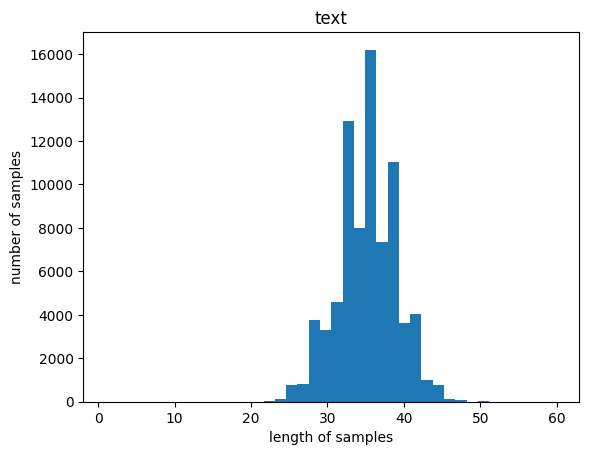

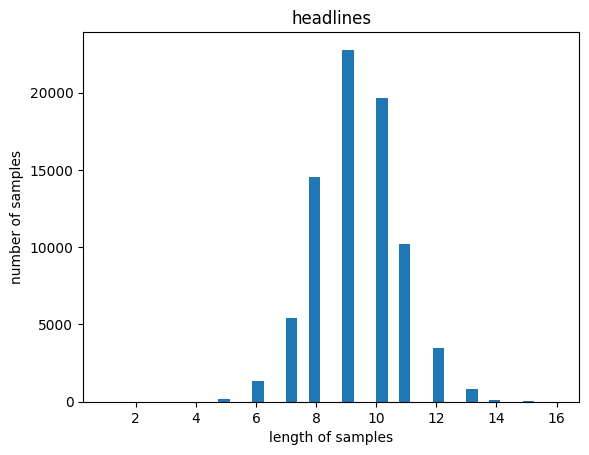

In [93]:
# 길이 분포 출력
import matplotlib.pyplot as plt
import numpy as np

text_len = [len(s.split()) for s in train['text']]
headlines_len = [len(s.split()) for s in train['headlines']]

print('텍스트의 최소 길이 : {}'.format(np.min(text_len)))
print('텍스트의 최대 길이 : {}'.format(np.max(text_len)))
print('텍스트의 평균 길이 : {}'.format(np.mean(text_len)))
print('요약의 최소 길이 : {}'.format(np.min(headlines_len)))
print('요약의 최대 길이 : {}'.format(np.max(headlines_len)))
print('요약의 평균 길이 : {}'.format(np.mean(headlines_len)))

plt.subplot(1,2,1)
plt.boxplot(text_len)
plt.title('text')
plt.subplot(1,2,2)
plt.boxplot(headlines_len)
plt.title('headlines')
plt.tight_layout()
plt.show()

plt.title('text')
plt.hist(text_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('headlines')
plt.hist(headlines_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [94]:
text_max_len = 45
headlines_max_len = 13

In [95]:
# 설정한 텍스트의 최대 길이로 얼마나 많은 샘플들을 자르지 않고 포함할 수 있는지 확인 해보기

def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s.split()) <= max_len):
        cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))))

below_threshold_len(text_max_len, train['text'])
below_threshold_len(headlines_max_len, train['headlines'])

전체 샘플 중 길이가 45 이하인 샘플의 비율: 0.9967560966301569
전체 샘플 중 길이가 13 이하인 샘플의 비율: 0.9982699182027504


In [96]:
# 텍스트의 최대 길이보다 큰 데이터는 버리기
# train을 통해 정한 최대 길이를 validation과 test에 똑같이 적용하기

train = train[train['text'].apply(lambda x: len(x.split()) <= text_max_len)]
train = train[train['headlines'].apply(lambda x: len(x.split()) <= headlines_max_len)]

val = val[val['text'].apply(lambda x: len(x.split()) <= text_max_len)]
val = val[val['headlines'].apply(lambda x: len(x.split()) <= headlines_max_len)]

test = test[test['text'].apply(lambda x: len(x.split()) <= text_max_len)]
test = test[test['headlines'].apply(lambda x: len(x.split()) <= headlines_max_len)]

### decoder에 사용되는 headlines 컬럼에 sos 토큰(시작 토큰)과 eos 토큰(종료 토큰) 추가하기

In [97]:
# Train
train['decoder_input'] = train['headlines'].apply(lambda x: 'sostoken ' + x)
train['decoder_target'] = train['headlines'].apply(lambda x: x + ' eostoken')

# Validation
val['decoder_input'] = val['headlines'].apply(lambda x: 'sostoken ' + x)
val['decoder_target'] = val['headlines'].apply(lambda x: x + ' eostoken')

# Test
test['decoder_input'] = test['headlines'].apply(lambda x: 'sostoken ' + x)
test['decoder_target'] = test['headlines'].apply(lambda x: x + ' eostoken')

# 확인
print(train[['headlines', 'decoder_input', 'decoder_target']].head())

                                                     headlines  \
0       karnataka village locals boycott voting in state polls   
1  have photos showing nun happy after alleged rape kerala mla   
2           us man who once sold trash fish is now billionaire   
3                  bjp and its allies now rule states in india   
4       do not call me his excellency rajya sabha chair to mps   

                                                          decoder_input  \
0       sostoken karnataka village locals boycott voting in state polls   
1  sostoken have photos showing nun happy after alleged rape kerala mla   
2           sostoken us man who once sold trash fish is now billionaire   
3                  sostoken bjp and its allies now rule states in india   
4       sostoken do not call me his excellency rajya sabha chair to mps   

                                                         decoder_target  
0       karnataka village locals boycott voting in state polls eostoken  
1  h

### 단어 집합(vocabulary) 만들기

In [98]:
def build_vocab(texts):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(text.split())  # 단어 빈도수 계산

    # 단어 집합 생성 (빈도가 높은 순서대로)
    for word, _ in word_counter.most_common():
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab

src_vocab = build_vocab(train['text'])

- 생성된 vocabulary에서 등장 횟수가 6 미만(threshold)인 단어

In [99]:
threshold = 6

# 전처리된 데이터 사용
text_data = train['text'].tolist()
# 단어 빈도수 계산
word_counter = Counter()
for text in text_data:
    word_counter.update(text.split())

total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

# 희귀 단어를 제외한 단어 사전 구축
vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩 및 미등록 단어 추가
word_index = {word: idx + 2 for idx, (word, count) in enumerate(word_counter.items()) if count >= threshold}

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 69279
등장 빈도가 5번 이하인 희귀 단어의 수: 45395
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 23884
단어 집합에서 희귀 단어의 비율: 65.52490653733454
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 3.0994729583561638


- 등장 빈도가 6 미만인 단어는 제외하고 단어 집합 생성하기
- 단어 집합의 크기는 src_vocab_size = 2300

In [100]:
src_vocab_size = 2000

def build_limited_vocab(texts, vocab_size):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(text.split())  # 단어 빈도수 계산

    # 빈도가 높은 상위 vocab_size - 2개 단어만 선택 (PAD, UNK 포함)
    for word, _ in word_counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)

    return vocab

src_vocab = build_limited_vocab(train['text'], src_vocab_size)

### 정수 인코딩

In [101]:
def text_to_sequence(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab["<UNK>"]) for word in text.split()]
        sequences.append(sequence)
    return sequences

# 텍스트 데이터 정수 시퀀스로 변환
encoder_input_train_seq = text_to_sequence(train['text'], src_vocab)
encoder_input_val_seq = text_to_sequence(val['text'], src_vocab)
encoder_input_test_seq = text_to_sequence(test['text'], src_vocab)

# 샘플 출력
print("Train:", encoder_input_train_seq[:3])
print("Validation:", encoder_input_val_seq[:3])
print("Test:", encoder_input_test_seq[:3])

Train: [[1337, 278, 1, 701, 1, 22, 287, 175, 87, 1104, 1, 1, 1, 701, 1337, 701, 198, 11, 1943, 1346, 343, 175, 1, 278, 287, 821, 1, 1], [330, 731, 1, 1, 33, 66, 330, 1, 1, 41, 1539, 1057, 1, 1, 1, 103, 447, 163, 648, 7, 1, 1, 1162, 1, 5, 1, 7, 43, 403, 42, 473, 465, 1, 1], [1, 1, 254, 1328, 920, 1, 1, 1, 1, 1, 1, 1071, 322, 1, 1329, 1, 1, 216, 70, 1, 263, 1, 887, 1, 1, 1, 1, 1, 1, 77, 1, 1]]
Validation: [[153, 140, 592, 1, 289, 1, 1, 1184, 1, 1, 1403, 1, 1, 1836, 141, 352, 1, 1, 357, 1, 1271, 252, 1, 1, 1, 550, 1807, 1, 1, 119, 74, 1271, 1668, 2, 234], [6, 1967, 1798, 377, 46, 205, 314, 1, 1, 1925, 1569, 732, 1, 902, 1, 940, 54, 32, 1, 1, 1741, 363, 1, 2, 1, 902, 1, 169, 1082, 71, 1, 1, 1, 1, 902, 1, 406, 1, 1449], [856, 134, 199, 536, 78, 1, 991, 1481, 1, 1, 883, 606, 206, 222, 1801, 1, 1, 58, 1, 1, 325, 1, 1, 1, 90, 1, 1, 266, 566, 1, 476, 1, 883, 1363, 1, 93, 1, 347]]
Test: [[42, 3, 375, 560, 1452, 1, 971, 803, 582, 12, 112, 42, 1, 1310, 145, 806, 1149, 313, 1, 105, 181, 381, 3, 155

- decoder_input 컬럼에도 동일하게 수행

In [102]:
tar_vocab = build_vocab(train['decoder_input'])

In [103]:
threshold = 6

word_counter = Counter()
for text in train['decoder_input']:
    word_counter.update(text.split())  # 각 문장의 단어 빈도 계산

# 전체 단어 개수 및 등장 빈도 계산
total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 29988
등장 빈도가 5번 이하인 희귀 단어의 수: 19604
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 10384
단어 집합에서 희귀 단어의 비율: 65.37281579298386
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 4.658988607084096


In [104]:
tar_vocab_size = 1000
# train['decoder_input'] / train['decoder_target'] 은 numpy 배열이므로 '+' 는 원소별 문자열 결합이 됩니다.
# 두 데이터를 하나의 리스트로 이어 붙여 단어 집합을 만듭니다.
tar_vocab = build_limited_vocab(list(train['decoder_input']) + list(train['decoder_target']), tar_vocab_size)

# 텍스트 시퀀스를 정수 시퀀스로 변환
decoder_input_train_seq = text_to_sequence(train['decoder_input'], tar_vocab)
decoder_target_train_seq = text_to_sequence(train['decoder_target'], tar_vocab)
decoder_input_val_seq = text_to_sequence(val['decoder_input'], tar_vocab)
decoder_target_val_seq = text_to_sequence(val['decoder_target'], tar_vocab)
decoder_input_test_seq = text_to_sequence(test['decoder_input'], tar_vocab)
decoder_target_test_seq = text_to_sequence(test['decoder_target'], tar_vocab)

# 확인
print('Train input')
print(decoder_input_train_seq[:5])

print('Train target')
print(decoder_target_train_seq[:5])

print('Validation input')
print(decoder_input_val_seq[:5])

print('Validation target')
print(decoder_target_val_seq[:5])

print('Test input')
print(decoder_input_test_seq[:5])

print('Test target')
print(decoder_target_test_seq[:5])

Train input
[[2, 317, 927, 1, 1, 1, 5, 215, 240], [2, 47, 1, 1, 1, 954, 12, 1, 148, 137, 267], [2, 14, 21, 42, 363, 609, 1, 1, 20, 238, 653], [2, 33, 49, 80, 1, 238, 1, 662, 5, 9], [2, 61, 11, 439, 73, 45, 1, 1, 765, 1, 4, 861]]
Train target
[[317, 927, 1, 1, 1, 5, 215, 240, 3], [47, 1, 1, 1, 954, 12, 1, 148, 137, 267, 3], [14, 21, 42, 363, 609, 1, 1, 20, 238, 653, 3], [33, 49, 80, 1, 238, 1, 662, 5, 9, 3], [61, 11, 439, 73, 45, 1, 1, 765, 1, 4, 861, 3]]
Validation input
[[2, 1, 90, 85, 47, 1, 1, 1], [2, 14, 1, 1, 1, 43, 1, 1, 1, 38], [2, 1, 196, 1, 762, 1, 1, 13, 232, 1, 1], [2, 57, 480, 1, 1, 1, 9, 1, 5, 416, 583, 1], [2, 56, 1, 153, 4, 1, 536, 10, 260, 7, 1, 1]]
Validation target
[[1, 90, 85, 47, 1, 1, 1, 3], [14, 1, 1, 1, 43, 1, 1, 1, 38, 3], [1, 196, 1, 762, 1, 1, 13, 232, 1, 1, 3], [57, 480, 1, 1, 1, 9, 1, 5, 416, 583, 1, 3], [56, 1, 153, 4, 1, 536, 10, 260, 7, 1, 1, 3]]
Test input
[[2, 244, 100, 9, 905, 274, 336, 1, 1, 4, 472], [2, 56, 1, 1, 4, 22, 1, 43, 1, 643], [2, 321, 206, 

- sos 토큰과 eos 토큰만 남은 경우 확인하고 제거

In [105]:
# 요약 데이터가 시작 토큰(sostoken)만 남아 사실상 비어 있는 샘플을 제거
drop_train = [index for index, seq in enumerate(decoder_input_train_seq) if len(seq) <= 1]
drop_val = [index for index, seq in enumerate(decoder_input_val_seq) if len(seq) <= 1]
drop_test  = [index for index, seq in enumerate(decoder_input_test_seq)  if len(seq) <= 1]

print('삭제할 훈련 데이터의 개수 :', len(drop_train))
print('삭제할 검증 데이터의 개수 :', len(drop_val))
print('삭제할 테스트 데이터의 개수 :', len(drop_test))

def _filter(seqs, drop):
    dropset = set(drop)
    return [s for i, s in enumerate(seqs) if i not in dropset]

encoder_input_train_seq  = _filter(encoder_input_train_seq,  drop_train)
decoder_input_train_seq  = _filter(decoder_input_train_seq,  drop_train)
decoder_target_train_seq = _filter(decoder_target_train_seq, drop_train)

encoder_input_val_seq  = _filter(encoder_input_val_seq,  drop_val)
decoder_input_val_seq  = _filter(decoder_input_val_seq,  drop_val)
decoder_target_val_seq = _filter(decoder_target_val_seq, drop_val)

encoder_input_test_seq  = _filter(encoder_input_test_seq,  drop_test)
decoder_input_test_seq  = _filter(decoder_input_test_seq,  drop_test)
decoder_target_test_seq = _filter(decoder_target_test_seq, drop_test)

print('훈련 데이터의 개수 :', len(encoder_input_train_seq))
print('훈련 레이블의 개수 :', len(decoder_input_train_seq))
print('검증 데이터의 개수 :', len(encoder_input_val_seq))
print('검증 레이블의 개수 :', len(decoder_input_val_seq))
print('테스트 데이터의 개수 :', len(encoder_input_test_seq))
print('테스트 레이블의 개수 :', len(decoder_input_test_seq))

삭제할 훈련 데이터의 개수 : 0
삭제할 검증 데이터의 개수 : 0
삭제할 테스트 데이터의 개수 : 0
훈련 데이터의 개수 : 78218
훈련 레이블의 개수 : 78218
검증 데이터의 개수 : 9777
검증 레이블의 개수 : 9777
테스트 데이터의 개수 : 9770
테스트 레이블의 개수 : 9770


- Padding

In [106]:
from torch.nn.utils.rnn import pad_sequence

# 텐서 변환 함수 (리스트 → PyTorch 텐서)
def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

# 패딩 적용 함수 (PyTorch의 pad_sequence() 활용)
def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    sequences = convert_to_tensor(sequences)  # 리스트를 텐서로 변환
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=padding_value)  # 패딩 적용
    return padded_seqs[:, :maxlen]  # maxlen 길이로 자르기 (최대 길이 초과 방지)

# 패딩 적용
encoder_input_train = pad_sequences_pytorch(encoder_input_train_seq, maxlen=text_max_len)
decoder_input_train = pad_sequences_pytorch(decoder_input_train_seq, maxlen=headlines_max_len)
decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, maxlen=headlines_max_len)

encoder_input_val = pad_sequences_pytorch(encoder_input_val_seq, maxlen=text_max_len)
decoder_input_val = pad_sequences_pytorch(decoder_input_val_seq, maxlen=headlines_max_len)
decoder_target_val = pad_sequences_pytorch(decoder_target_val_seq, maxlen=headlines_max_len)

encoder_input_test = pad_sequences_pytorch(encoder_input_test_seq, maxlen=text_max_len)
decoder_input_test = pad_sequences_pytorch(decoder_input_test_seq, maxlen=headlines_max_len)
decoder_target_test = pad_sequences_pytorch(decoder_target_test_seq, maxlen=headlines_max_len)

# 4. 모델 설계

## Attention + seq2seq (추상적 요약)



```
      encoder_input
      (기사 본문)
            ↓
        Encoder
            ↓
 ┌───-─┴-────┐
 ↓                    ↓
encoder_outputs    hidden, cell
 ↓                    ↓
 ↓                 Decoder
 ↓                    ↓
 └────────────→ decoder_outputs
                     ↓          
               Attention
              ↙         ↖
encoder_outputs      decoder_outputs
              ↓
          Attention Weight
              ↓
        Context Vector
              ↓
decoder_outputs + Context Vector
              ↓
            Linear
              ↓
       target vocabulary
              ↓
        다음 단어 예측
```



**1. Encoder**

입력 문장을 읽고 각 토큰의 정보(encoder_outputs)와 마지막 상태(hidden, cell)를 만든다.

```text
입력 문장
    ↓
정수 시퀀스
    ↓
Embedding
    ↓
LSTM Layer 1
    ↓
LSTM Layer 2
    ↓
LSTM Layer 3
    ↓
encoder_outputs(입력 문장의 각 토큰 위치마다 만들어진 LSTM 출력, Attention에서 사용)
hidden(Encoder의 마지막 hidden state, Decoder의 초기 입력값)
cell(Encoder의 마지막 cell state, Decoder의 초기 입력값)

In [107]:
import torch.nn as nn
import torch.nn.functional as F

# 인코더 설계 시작
embedding_dim = 128
hidden_size = 256                # LSTM이 문맥 정보를 표현할 때 256개의 숫자를 사용한다는 의미(출력)
                                 # 256개의 숫자를 Attention과 linear를 이용해 vocabulary에 있는 모든 단어에 대한 점수로 변환하는 것
src_vocab_size = len(src_vocab)  # 단어 집합 크기

# 인코더
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            dropout=dropout, batch_first=True
        )

    def forward(self, x): # 인코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)  # LSTM 실행
        return output, hidden, cell

# 인코더 모델 생성
encoder = Encoder(src_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

**2. Decoder**

Encoder의 hidden, cell을 초기 상태로 받아 출력 문장을 생성한다.


```
decoder_input
    ↓
Embedding
    ↓
LSTM Layer 1
    ↓
LSTM Layer 2
    ↓
LSTM Layer 3
    ↓
batch
tgt_len
hidden_size
```



In [108]:
# 디코더 설계
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.4, num_layers=3):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell): # 디코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # 초기 상태를 인코더에서 전달받음
        return output, hidden, cell

# 디코더 모델 생성
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

**3. Seq2Seq**

Encoder와 Decoder를 연결한다.

각 Decoder 시점마다 다음에 나올 단어 후보 전체에 대한 점수(logit)가 만들어진다.



```
encoder_input
      ↓
   Encoder
      ↓
   Decoder
      ↓
    Linear
      ↓
target vocabulary 크기의 로짓
```



In [109]:
# 디코더의 출력층
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, vocab_size):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.softmax_layer = nn.Linear(hidden_size, vocab_size)  # 출력층 정의

    def forward(self, encoder_input, decoder_input):
        # 인코더 실행
        encoder_output, hidden, cell = self.encoder(encoder_input)

        # 디코더 실행
        decoder_output, _, _ = self.decoder(decoder_input, hidden, cell)

        # 출력층 적용 (Softmax는 Loss 내부에서 적용되므로 생략 가능)
        output = self.softmax_layer(decoder_output)
        return output

# 모델 정의
model = Seq2Seq(encoder, decoder, tar_vocab_size)
print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(2000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(1000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (softmax_layer): Linear(in_features=256, out_features=1000, bias=True)
)


**4. Attention**

Decoder가 현재 단어를 생성할 때 Encoder의 어떤 입력 토큰을 중요하게 볼지 결정한다.



```
① Attention Score 계산(Dot Product)
Decoder의 출력과 Encoder의 각 출력 사이의 유사도를 계산한다.

② Softmax
Score를 Softmax에 통과시켜 Attention Weight를 만든다.

③ Context Vector 계산
Attention Weight를 Encoder 출력에 곱해서 가중합한다.
```



In [110]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()

    def forward(self, decoder_output, encoder_outputs):

        # Attention Score 계산
        attn_weights = torch.bmm(
            decoder_output,
            encoder_outputs.transpose(1, 2)
        )

        # Attention Weight
        attn_weights = F.softmax(
            attn_weights,
            dim=-1
        )

        # Context Vector
        attn_out = torch.bmm(
            attn_weights,
            encoder_outputs
        )

        return attn_out


class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, vocab_size, hidden_size):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = Attention(hidden_size)
        self.concat = nn.Linear(hidden_size * 2, hidden_size)   # 디코더출력+문맥벡터 결합용
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 단어 확률(로짓) 출력용

    def forward(self, encoder_input, decoder_input):
        # 인코더 실행: 전체 시점 출력(encoder_outputs)과 마지막 상태(hidden, cell) 획득
        encoder_outputs, hidden, cell = self.encoder(encoder_input)

        # 인코더의 마지막 hidden/cell을 초기 상태로 받아 디코더 실행
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        # 어텐션 적용: 디코더 각 시점에 맞는 인코더 문맥 벡터 계산
        attn_out = self.attention(decoder_outputs, encoder_outputs)

        # 디코더 자체 출력 + 어텐션 문맥 벡터를 이어붙이기 (마지막 차원 기준)
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)

        # 이어붙인 벡터를 다시 hidden_size로 압축 (Linear + tanh로 정보 융합)
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))

        # 최종적으로 vocab_size 크기의 출력(다음 단어 예측용 로짓) 생성
        output = self.output_layer(decoder_concat_output)

        return output


# 모델 생성
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size)
print(model)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(2000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(1000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=1000, bias=True)
)


### 모델 훈련하기

In [111]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Hyperparameters
batch_size = 256
epochs = 50
learning_rate = 0.001
patience = 2

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 패딩 토큰 무시
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# PyTorch DataLoader 설정
train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
val_dataset = TensorDataset(encoder_input_val, decoder_input_val, decoder_target_val)
test_dataset = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


In [112]:
train_losses = []
val_losses = []

# 학습 함수
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, patience):
    model.train()
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        total_loss = 0

        for encoder_input, decoder_input, target in train_loader:
            optimizer.zero_grad()

            # 정수형 변환
            encoder_input = encoder_input.to(device).long()
            decoder_input = decoder_input.to(device).long()
            target = target.to(device).long()

            # 모델 실행
            output = model(encoder_input, decoder_input)
            output = output.view(-1, output.shape[-1])    # CrossEntropyLoss에 맞게 변환
            target = target.view(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation loss 계산
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for encoder_input, decoder_input, target in val_loader:
                encoder_input = encoder_input.to(device).long()
                decoder_input = decoder_input.to(device).long()
                target = target.to(device).long()

                output = model(encoder_input, decoder_input)
                output = output.view(-1, output.shape[-1])
                target = target.view(-1)
                loss = criterion(output, target)

                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping 조건
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0

            torch.save(      # 가장 좋은 모델 저장
                model.state_dict(),
                "best_model.pt"
            )
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        model.train()

In [113]:
%%time
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=patience)

Epoch 1/50 | Train Loss: 4.0861 | Val Loss: 3.8639
Epoch 2/50 | Train Loss: 3.7699 | Val Loss: 3.6025
Epoch 3/50 | Train Loss: 3.4910 | Val Loss: 3.3450
Epoch 4/50 | Train Loss: 3.2580 | Val Loss: 3.1611
Epoch 5/50 | Train Loss: 3.0832 | Val Loss: 3.0215
Epoch 6/50 | Train Loss: 2.9419 | Val Loss: 2.9090
Epoch 7/50 | Train Loss: 2.8230 | Val Loss: 2.8222
Epoch 8/50 | Train Loss: 2.7230 | Val Loss: 2.7546
Epoch 9/50 | Train Loss: 2.6346 | Val Loss: 2.7018
Epoch 10/50 | Train Loss: 2.5565 | Val Loss: 2.6633
Epoch 11/50 | Train Loss: 2.4850 | Val Loss: 2.6297
Epoch 12/50 | Train Loss: 2.4211 | Val Loss: 2.6101
Epoch 13/50 | Train Loss: 2.3622 | Val Loss: 2.5933
Epoch 14/50 | Train Loss: 2.3074 | Val Loss: 2.5850
Epoch 15/50 | Train Loss: 2.2587 | Val Loss: 2.5857
Epoch 16/50 | Train Loss: 2.2111 | Val Loss: 2.5818
Epoch 17/50 | Train Loss: 2.1671 | Val Loss: 2.5807
Epoch 18/50 | Train Loss: 2.1264 | Val Loss: 2.5890
Epoch 19/50 | Train Loss: 2.0876 | Val Loss: 2.5952
Early stopping trigge

### 학습 결과 시각화

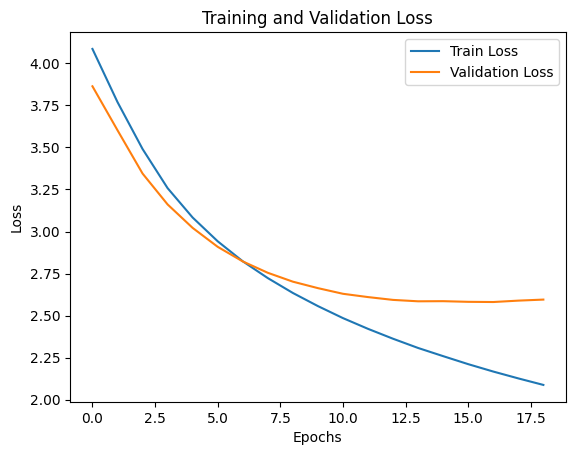

In [114]:
plt.plot(range(len(train_losses)), train_losses, label='Train Loss')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

### 인퍼런스 모델 생성

In [115]:
src_index_to_word = {idx: word for word, idx in src_vocab.items()} # 원문 단어 집합에서 정수 -> 단어를 얻음
tar_word_to_index = tar_vocab                                      # 요약 단어 집합에서 단어 -> 정수를 얻음
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()} # 요약 단어 집합에서 정수 -> 단어를 얻음

In [116]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(2000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(1000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=1000, bias=True)
)



```
훈련된 model
     │
     ├── Decoder ─────-┐
     ├── Attention ────-┤
     ├── concat ──────┤
     └── output_layer ───┘
                               ↓
                        InferenceDecoder
```



In [117]:
# 훈련된 Seq2SeqWithAttention 모델의 구성요소(디코더/어텐션/결합층/출력층)를
# 그대로 재사용하여 '한 스텝'씩 단어를 생성하는 래퍼
# 새로운 파라미터를 만들지 않으므로 훈련된 가중치가 그대로 사용됨
class InferenceDecoder(nn.Module):
    def __init__(self, model):
        super(InferenceDecoder, self).__init__()
        self.decoder = model.decoder            # 학습된 디코더 LSTM
        self.attention = model.attention        # 학습된 어텐션
        self.concat = model.concat              # 학습된 결합층
        self.output_layer = model.output_layer  # 학습된 출력층

    def forward(self, decoder_input, hidden, cell, encoder_outputs):
        # decoder_input: (1, 1)  -> 한 시점의 토큰 하나
        decoder_outputs, hidden, cell = self.decoder(decoder_input, hidden, cell)
        attn_out = self.attention(decoder_outputs, encoder_outputs)
        concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)
        concat_output = torch.tanh(self.concat(concat_output))
        logits = self.output_layer(concat_output)  # (1, 1, vocab) — argmax만 할 것이라 softmax 불필요
        return logits, hidden, cell

inference_decoder = InferenceDecoder(model)
inference_decoder.to(device)
inference_decoder.eval()

InferenceDecoder(
  (decoder): Decoder(
    (embedding): Embedding(1000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=1000, bias=True)
)

In [118]:
def decode_sequence(input_seq, model, inference_decoder, tar_word_to_index,
                    tar_index_to_word, text_max_len, summary_max_len, device):
    model.eval()
    inference_decoder.eval()

    # 입력을 (1, src_len) 텐서로 변환
    if not torch.is_tensor(input_seq):
        input_seq = torch.tensor(input_seq, dtype=torch.long)
    input_seq = input_seq.to(device).long()
    if input_seq.dim() == 1:
        input_seq = input_seq.unsqueeze(0)

    # 인코더를 한 번 실행하여 인코더 출력과 초기 상태(hidden, cell)를 얻습니다.
    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(input_seq)

    # 시작 토큰(sostoken)으로 디코딩을 시작합니다.
    target_seq = torch.tensor([[tar_word_to_index['sostoken']]], dtype=torch.long, device=device)

    decoded_sentence = ''
    for _ in range(summary_max_len):
        with torch.no_grad():
            logits, hidden, cell = inference_decoder(target_seq, hidden, cell, encoder_outputs)

        sampled_token_index = int(torch.argmax(logits[0, -1, :]).item())
        sampled_token = tar_index_to_word.get(sampled_token_index, '')

        # 종료 토큰을 만나면 중단
        if sampled_token == 'eostoken':
            break
        if sampled_token not in ('', '<PAD>', '<UNK>', 'sostoken'):
            decoded_sentence += ' ' + sampled_token

        # 방금 예측한 토큰을 다음 시점의 입력으로 사용 (auto-regressive)
        target_seq = torch.tensor([[sampled_token_index]], dtype=torch.long, device=device)

    return decoded_sentence.strip()

### 모델 테스트를 위한 함수

In [119]:
# text의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2text(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0:  # 패딩(0) 제외
            temp = temp + src_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()

# headlines의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2headlines(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0 and key != tar_word_to_index['sostoken'] and key != tar_word_to_index['eostoken']:
            temp = temp + tar_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()  # 양쪽 공백 제거

## summa (추출적 요약)

# 5. LSTM과 Summa 테스트

In [120]:
from summa import summarizer
import pandas as pd
import torch

# Summa용 원본 Test 데이터 불러오기
summa_test = pd.read_csv(
    '/content/drive/MyDrive/summa_test.csv',
    encoding='utf-8-sig'
)


# 가장 성능이 좋았던 모델 불러오기
model.load_state_dict(
    torch.load(
        "best_model.pt",
        map_location=device
    )
)

model.to(device)
model.eval()

inference_decoder = InferenceDecoder(model)
inference_decoder.to(device)
inference_decoder.eval()


results = []


for i in range(len(encoder_input_test)):

    # 1. Summa에서 사용할 text
    original_text = summa_test['text'].iloc[i]


    # 2. Summa에서 사용할 headlines
    actual_headline = summa_test['headlines'].iloc[i]


    # 3. LSTM + Attention
    attention_summary = decode_sequence(
        encoder_input_test[i],
        model,
        inference_decoder,
        tar_word_to_index,
        tar_index_to_word,
        text_max_len,
        headlines_max_len,
        device
    )


    # 4. Summa
    summa_summary = summarizer.summarize(
        original_text,
        words=20
    )


    # 5. 결과 저장
    results.append({
        'index': i,
        'text': original_text,
        'headline': actual_headline,
        'attention_summary': attention_summary,
        'summa_summary': summa_summary
    })


    # 진행 상황 출력
    if (i + 1) % 100 == 0:
        print(
            f"{i + 1} / {len(encoder_input_test)} 완료"
        )

100 / 9770 완료
200 / 9770 완료
300 / 9770 완료
400 / 9770 완료
500 / 9770 완료
600 / 9770 완료
700 / 9770 완료
800 / 9770 완료
900 / 9770 완료
1000 / 9770 완료
1100 / 9770 완료
1200 / 9770 완료
1300 / 9770 완료
1400 / 9770 완료
1500 / 9770 완료
1600 / 9770 완료
1700 / 9770 완료
1800 / 9770 완료
1900 / 9770 완료
2000 / 9770 완료
2100 / 9770 완료
2200 / 9770 완료
2300 / 9770 완료
2400 / 9770 완료
2500 / 9770 완료
2600 / 9770 완료
2700 / 9770 완료
2800 / 9770 완료
2900 / 9770 완료
3000 / 9770 완료
3100 / 9770 완료
3200 / 9770 완료
3300 / 9770 완료
3400 / 9770 완료
3500 / 9770 완료
3600 / 9770 완료
3700 / 9770 완료
3800 / 9770 완료
3900 / 9770 완료
4000 / 9770 완료
4100 / 9770 완료
4200 / 9770 완료
4300 / 9770 완료
4400 / 9770 완료
4500 / 9770 완료
4600 / 9770 완료
4700 / 9770 완료
4800 / 9770 완료
4900 / 9770 완료
5000 / 9770 완료
5100 / 9770 완료
5200 / 9770 완료
5300 / 9770 완료
5400 / 9770 완료
5500 / 9770 완료
5600 / 9770 완료
5700 / 9770 완료
5800 / 9770 완료
5900 / 9770 완료
6000 / 9770 완료
6100 / 9770 완료
6200 / 9770 완료
6300 / 9770 완료
6400 / 9770 완료
6500 / 9770 완료
6600 / 9770 완료
6700 / 9770 완료
6800

In [123]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

comparison_df = pd.DataFrame(results)
comparison_df.head(5)

,index,text,headline,attention_summary,summa_summary
0,0,"Team India head coach Ravi Shastri has urged the BCCI to provide the Indian cricket team adequate break between series in the future to avoid player burnout. Notably, Australia will visit India for a limited-overs tour in September, four days after which India will host New Zealand. The team will then be given a week-long break before hosting Sri Lanka.",Give Team India a break: Head coach Ravi Shastri to BCCI,india coach bcci to play team series series,The team will then be given a week-long break before hosting Sri Lanka.
1,1,"The Mumbai Police has asked the Brihanmumbai Municipal Corporation and Maharashtra government to secure the Marine Drive against potential terror car attacks, according to reports. The police sought to either raise the height of the promenade, which would make it difficult for vehicles to climb on it, or install short posts to cut the speed of the incoming vehicles.",Mumbai's Marine Drive to be secured against vehicle attacks,mumbai police orders of,"The Mumbai Police has asked the Brihanmumbai Municipal Corporation and Maharashtra government to secure the Marine Drive against potential terror car attacks, according to reports."
2,2,"Disciplinary action has been recommended against 52 policemen, many of them in senior positions, for allegedly aiding and encouraging illegal liquor trade in Bihar, where liquor sale is prohibited. This comes following Bihar Chief Minister Nitish Kumar's directive for ""exemplary punishment"" against policemen who allow and abet illegal liquor trade in the state.",52 cops under scanner over illegal liquor trade in dry Bihar,police police liquor,"Disciplinary action has been recommended against 52 policemen, many of them in senior positions, for allegedly aiding and encouraging illegal liquor trade in Bihar, where liquor sale is prohibited."
3,3,"A Chinese farmer-turned-mechanic has constructed a life-sized Airbus A320 replica to fulfil his childhood dream of owning a plane. It took Zhu Yue two years and $400,000 to build the replica, which has been made from over 50 tons of steel. The engine 'turbines' in the replica can actually spin, however, the aircraft replica does not fly.",Chinese farmer builds Airbus A320 replica to fulfil childhood dream,chinese life,A Chinese farmer-turned-mechanic has constructed a life-sized Airbus A320 replica to fulfil his childhood dream of owning a plane.
4,4,"After two BJP workers were found hanging in West Bengal's Balrampur district this week, BJP leader Shahnawaz Hussain termed the ruling Trinamool Congress (TMC) party as the ""Taliban Congress party"". Stating that the party should fight the BJP through ideology, Hussain accused the police of colluding with the TMC. Mamata Banerjee should resign as the Chief Minister, he added.",TMC is Taliban Congress Party: BJP after workers' death,bjp workers in west bengal,"After two BJP workers were found hanging in West Bengal's Balrampur district this week, BJP leader Shahnawaz Hussain termed the ruling Trinamool Congress (TMC) party as the ""Taliban Congress party""."


# 6. 결과 분석

**LSTM + Attention**

원문의 핵심 단어를 일부 반영하지만 전체적인 문장 생성 품질은 낮음.
police police liquor, chinese life처럼 반복되거나 지나치게 짧은 요약이 나타남.
실제 제목과 관련된 단어를 생성하는 경우도 있지만 문법적으로 자연스럽지 않음.



**Summa**

원문에서 핵심 내용을 포함한 문장을 추출하여 실제 제목과 비교적 유사한 내용을 보여줌.
문장 자체를 생성하지 않고 원문의 문장을 추출하기 때문에 문법적으로 자연스럽고 정보 손실이 적음.

**LSTM + Attention 성능이 낮은 원인 추정**

**1. Greedy Decoding의 한계**

매 시점마다 가장 확률이 높은 단어 하나만 선택하는 argmax 방식을 사용함.
이로 인해 series series처럼 동일한 단어가 반복되는 현상이 발생함.

**2. Teacher Forcing과 실제 추론의 차이**

학습에서는 정답 단어를 다음 입력으로 사용하지만 추론에서는 모델이 예측한 단어를 다음 입력으로 사용함.
즉, 초기 예측이 틀리면 이후 예측에도 오류가 누적될 수 있음.

**3. Seq2Seq + Attention 모델의 한계**

현재 모델은 비교적 단순한 LSTM 기반 구조이며 뉴스의 긴 문맥과 다양한 표현을 충분히 학습하기 어려울 수 있음.
학습 데이터에 비해 모델이 복잡한 요약을 생성하기에는 한계가 있음.

**4. 학습과 추론 결과의 차이**

Train Loss는 4.11 → 2.24, Validation Loss는 3.90 → 2.62로 감소하여 학습 자체는 정상적으로 진행됨.
따라서 단순한 학습 실패보다는 실제 문장 생성 과정에서의 문제가 성능 저하에 크게 영향을 준 것으로 판단됨.